   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Accuracy: 0.7395833333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80       123
           1       0.65      0.61      0.63        69

    accuracy                           0.74       192
   macro avg       0.72      0

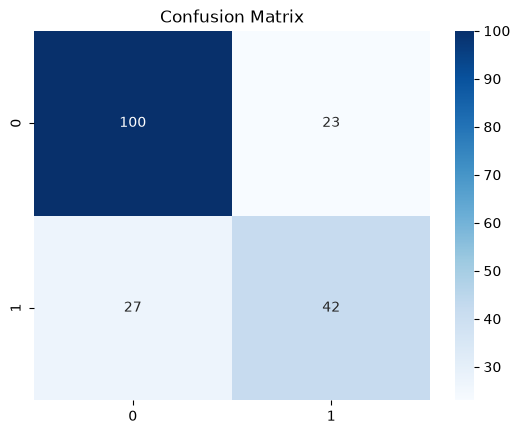

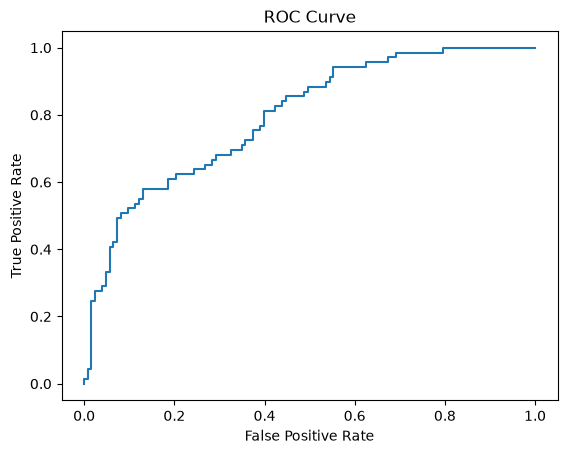

AUC Score:  0.7946270767055498

Model and scaler saved successfully as 'diabetes_model.pkl' and 'scaler.pkl'!


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import joblib

df = pd.read_csv("diabetes.csv")
print(df.head())

cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols:
    df[col] = df[col].replace(0,np.nan)
    df[col] = df[col].fillna(df[col].median())

#Train-Test Split
X = df.drop("Outcome",axis = 1)
y = df["Outcome"]

X_train, X_test, y_train , y_test = train_test_split(
    X,y, test_size = 0.25 , random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("\nAccuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

#ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr,tpr,_=roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score: ", roc_auc_score(y_test , y_prob))

#Save Model & Scaler for Streamlit App
joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully as 'diabetes_model.pkl' and 'scaler.pkl'!")